# Demo exhaustive du simulateur échographique

Ce notebook montre **toutes les fonctionnalités** principales du projet:
- CLI (commande implicite et explicite `simulate`)
- chargement scène JSON (`--scene` et alias `--json-file`)
- chargement paramètres JSON (`--config`)
- surcharges (`--snr`, `--nelem`)
- génération de scènes aléatoires (`--num`, `--max-point`)
- modes DAS et MVDR (`--mvdr`)
- mode validation sans exécution (`--dry-run`)
- prévisualisation de scène (`--preview-scene`)
- reproductibilité par seed (`--seed`)
- inspection des sorties (`h5`, `images`, `run.json`)
- API Python `core/*` (sans passer par la CLI)
- validation d'erreurs (`ValidationError`)

## Installation des dépendances

Exécutez la cellule suivante pour installer toutes les dépendances requises si elles ne sont pas encore installées.


In [ ]:
import subprocess
import sys

# Liste des dépendances requises
dependencies = [
    "numpy",
    "scipy",
    "h5py",
    "matplotlib"
]

print("🔧 Vérification et installation des dépendances...\n")

for package in dependencies:
    try:
        __import__(package)
        print(f" {package} est déjà installé")
    except ImportError:
        print(f" Installation de {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
        print(f" {package} a été installé avec succès")

print("\n✨ Toutes les dépendances sont prêtes!")

Les objectifs de ce notebook sont les suivants :

    - Montrer comment utiliser le simulateur
    - Offrir un moyen de génération de dataset plus simple que la ligne de commande
    - Étudier les différents cas de simulation possibles avec le simulateur

# I) Utilisation du simulateur


## 1) Préparation

Cette cellule détecte la racine du projet et prépare un dossier de sortie dédié au notebook.

In [16]:
from pathlib import Path
import subprocess
import sys
import shutil
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()

# Recherche robuste de la racine du projet (contient simulateur/main.py et simulateur/core/)
project_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "simulateur" / "main.py").exists() and (candidate / "simulateur" / "core").is_dir():
        project_root = candidate
        break
if project_root is None:
    raise RuntimeError(f"Impossible de localiser la racine du projet depuis {cwd}")

sim_root = project_root / "simulateur"
if str(sim_root) not in sys.path:
    sys.path.insert(0, str(sim_root))

print("Working dir notebook:", cwd)
print("Project root:", project_root)
print("Sim root:", sim_root)
print("Python:", sys.executable)

out_root = project_root / "demo" / "out"
out_root.mkdir(parents=True, exist_ok=True)
print("Output root:", out_root)

# Compat: le reste du notebook utilise repo_root
repo_root = sim_root


Working dir notebook: /home/tom/3A/PROCOM/code/demo
Project root: /home/tom/3A/PROCOM/code
Sim root: /home/tom/3A/PROCOM/code/simulateur
Python: /usr/bin/python
Output root: /home/tom/3A/PROCOM/code/demo/out


## 2) Helpers utilitaires

`run_cli(...)` exécute la CLI du simulateur et affiche stdout/stderr.

In [17]:
def run_cli(args, check=True):
    cmd = [sys.executable, "main.py", *args]
    print("$", " ".join(cmd))
    res = subprocess.run(cmd, cwd=repo_root, capture_output=True, text=True)
    if res.stdout:
        print(res.stdout)
    if res.stderr:
        print("[stderr]" + res.stderr)
    if check and res.returncode != 0:
        raise RuntimeError(f"Commande échouée (code={res.returncode})")
    return res


def read_run_json(run_dir):
    p = Path(run_dir) / "run.json"
    data = json.loads(p.read_text(encoding="utf-8"))
    print(json.dumps(data, indent=2)[:3000])
    return data


def display_generated_images(run_dir, title=None, max_images=12):
    run_dir = Path(run_dir)
    pngs = sorted((run_dir / "images").glob("*.png"))
    if not pngs:
        print(f"Aucune image PNG dans {run_dir / 'images'}")
        return

    if title:
        print(title)
    print(f"{len(pngs)} image(s) trouvée(s)")

    pngs = pngs[:max_images]
    n = len(pngs)
    cols = min(3, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = np.array([axes])
    elif cols == 1:
        axes = np.array([[ax] for ax in axes])

    for i, png in enumerate(pngs):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        img = plt.imread(png)
        ax.imshow(img)
        ax.set_title(png.name)
        ax.axis("off")

    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        axes[r, c].axis("off")

    plt.tight_layout()
    plt.show()


## 3) Aide CLI et options disponibles

Affiche l'aide globale et l'aide de la sous-commande explicite `simulate`.

In [18]:
run_cli(["--help"])
run_cli(["simulate", "--help"])

$ /usr/bin/python main.py --help
usage: main.py simulate [-h] [--config CONFIG] [--scene SCENE_PATH]
                        [--num NUM] [--out OUT] [--snr SNR] [--nelem NELEM]
                        [--seed SEED] [--mvdr] [--max-point MAX_POINT]
                        [--dry-run] [--preview-scene]

options:
  -h, --help            show this help message and exit
  --config CONFIG       Path to parameters JSON
  --scene, --json-file SCENE_PATH
                        Path to scene JSON (points/layers)
  --num NUM             Number of images (ignored if scene is provided unless
                        forced).
  --out OUT             Output directory
  --snr SNR             SNR in dB
  --nelem NELEM         Number of elements
  --seed SEED           Base seed
  --mvdr                Enable MVDR
  --max-point MAX_POINT
                        Max points per random scene
  --dry-run             Validate inputs without running simulation
  --preview-scene       Print scene summary (requ

CompletedProcess(args=['/usr/bin/python', 'main.py', 'simulate', '--help'], returncode=0, stdout='\x1busage: \x1b\x1bmain.py simulate\x1b [\x1b-h\x1b[0m] [\x1b--config \x1bCONFIG\x1b[0m] [\x1b--scene \x1bSCENE_PATH\x1b[0m]\n                        [\x1b--num \x1bNUM\x1b[0m] [\x1b--out \x1bOUT\x1b[0m] [\x1b--snr \x1bSNR\x1b[0m] [\x1b--nelem \x1bNELEM\x1b[0m]\n                        [\x1b--seed \x1bSEED\x1b[0m] [\x1b--mvdr\x1b[0m] [\x1b--max-point \x1bMAX_POINT\x1b[0m]\n                        [\x1b--dry-run\x1b[0m] [\x1b--preview-scene\x1b[0m]\n\n\x1boptions:\x1b\n  \x1b-h\x1b, \x1b--help\x1b            show this help message and exit\n  \x1b--config\x1b \x1bCONFIG\x1b       Path to parameters JSON\n  \x1b--scene\x1b, \x1b--json-file\x1b \x1bSCENE_PATH\x1b\n                        Path to scene JSON (points/layers)\n  \x1b--num\x1b \x1bNUM\x1b             Number of images (ignored if scene is provided unless\n                        forced).\n  \x1b--out\x1b \x1bOUT\x1b             Out

## 4) `--dry-run` (validation sans simulation)

Le dry-run permet de valider le bon fonctionnement du simulateur après l'implemenation de nouvelle fonctionnaliter. Cette option lance la generation de 10 image en mode DAS afin de voir si aucune regression n'as été introduite lors du developpement.

Cas 1: mode aléatoire par défaut (pas de scène, 10 images implicites).  
Cas 2: avec scène fournie (1 image implicite).

In [19]:
run_cli(["--dry-run"])
run_cli(["--scene", "scene/scene_simple.json", "--dry-run", "--seed", "7"])

$ /usr/bin/python main.py --dry-run
Dry run: 10 image(s), mode=das, seed=0

$ /usr/bin/python main.py --scene scene/scene_simple.json --dry-run --seed 7
Dry run: 1 image(s), mode=das, seed=7



CompletedProcess(args=['/usr/bin/python', 'main.py', '--scene', 'scene/scene_simple.json', '--dry-run', '--seed', '7'], returncode=0, stdout='Dry run: 1 image(s), mode=das, seed=7\n', stderr='')

## 5) `--preview-scene`

Affiche un résumé de la scène JSON (points et couches).

In [20]:
run_cli(["--scene", "scene/scene.json", "--preview-scene", "--dry-run"])

$ /usr/bin/python main.py --scene scene/scene.json --preview-scene --dry-run
points: 2
layers: 1
  - Graisse: 0.03..0.035 m, c=1455.0, rho=2500.0
Dry run: 1 image(s), mode=das, seed=0



CompletedProcess(args=['/usr/bin/python', 'main.py', '--scene', 'scene/scene.json', '--preview-scene', '--dry-run'], returncode=0, stdout='points: 2\nlayers: 1\n  - Graisse: 0.03..0.035 m, c=1455.0, rho=2500.0\nDry run: 1 image(s), mode=das, seed=0\n', stderr='')

## 6) Simulation DAS avec scène (`--scene`)

Exécute une simulation complète et inspecte les fichiers produits.

$ /usr/bin/python main.py --scene scene/scene_simple.json --out /home/tom/3A/PROCOM/code/demo/out/das_scene --num 1 --seed 42
Saved: /home/tom/3A/PROCOM/code/demo/out/das_scene/h5/sample_0000.h5

H5: [PosixPath('/home/tom/3A/PROCOM/code/demo/out/das_scene/h5/sample_0000.h5')]
PNG: [PosixPath('/home/tom/3A/PROCOM/code/demo/out/das_scene/images/sample_0000.png')]
{
  "beamforming": "das",
  "cli": {
    "command": "simulate",
    "config": null,
    "dry_run": false,
    "max_point": 3,
    "mvdr": false,
    "nelem": null,
    "num": 1,
    "out": "/home/tom/3A/PROCOM/code/demo/out/das_scene",
    "preview_scene": false,
    "scene_path": "scene/scene_simple.json",
    "seed": 42,
    "snr": null
  },
  "created_at": "2026-03-16T09:18:01.563012+00:00",
  "git_revision": null,
  "num_images": 1,
  "outputs": [
    {
      "h5": "/home/tom/3A/PROCOM/code/demo/out/das_scene/h5/sample_0000.h5",
      "index": 0,
      "png": "/home/tom/3A/PROCOM/code/demo/out/das_scene/images/sample_0000.pn

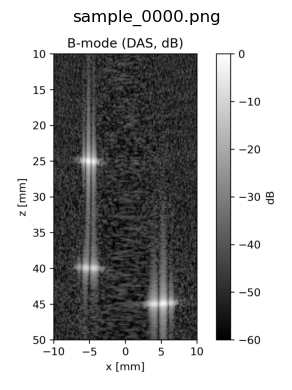

In [21]:
out_das_scene = out_root / "das_scene"
if out_das_scene.exists():
    shutil.rmtree(out_das_scene)

run_cli([
    "--scene", "scene/scene_simple.json",
    "--out", str(out_das_scene),
    "--num", "1",
    "--seed", "42"
])

print("H5:", sorted((out_das_scene / "h5").glob("*.h5")))
print("PNG:", sorted((out_das_scene / "images").glob("*.png")))
manifest_das_scene = read_run_json(out_das_scene)
display_generated_images(out_das_scene, title="Images générées (DAS - scène)")


## 7) Alias `--json-file` + sous-commande explicite `simulate`

Même fonctionnalité via l'alias historique.

$ /usr/bin/python main.py simulate --json-file scene/scene_simple.json --out /home/tom/3A/PROCOM/code/demo/out/alias_json_file --num 1 --seed 123
Saved: /home/tom/3A/PROCOM/code/demo/out/alias_json_file/h5/sample_0000.h5

{
  "beamforming": "das",
  "cli": {
    "command": "simulate",
    "config": null,
    "dry_run": false,
    "max_point": 3,
    "mvdr": false,
    "nelem": null,
    "num": 1,
    "out": "/home/tom/3A/PROCOM/code/demo/out/alias_json_file",
    "preview_scene": false,
    "scene_path": "scene/scene_simple.json",
    "seed": 123,
    "snr": null
  },
  "created_at": "2026-03-16T09:18:03.463299+00:00",
  "git_revision": null,
  "num_images": 1,
  "outputs": [
    {
      "h5": "/home/tom/3A/PROCOM/code/demo/out/alias_json_file/h5/sample_0000.h5",
      "index": 0,
      "png": "/home/tom/3A/PROCOM/code/demo/out/alias_json_file/images/sample_0000.png",
      "scene": {
        "layers": [],
        "points": [
          [
            -0.005,
            0.04,
          

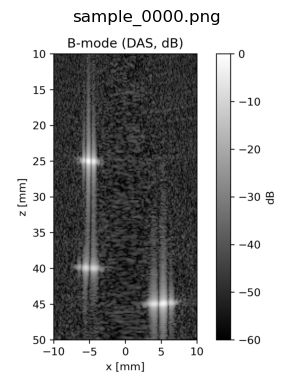

In [22]:
out_alias = out_root / "alias_json_file"
if out_alias.exists():
    shutil.rmtree(out_alias)

run_cli([
    "simulate",
    "--json-file", "scene/scene_simple.json",
    "--out", str(out_alias),
    "--num", "1",
    "--seed", "123"
])

manifest_alias = read_run_json(out_alias)
display_generated_images(out_alias, title="Images générées (--json-file)")


## 8) `--config` + surcharges `--snr` et `--nelem`

Montre le chargement de paramètres JSON puis surcharges ponctuelles en CLI.

$ /usr/bin/python main.py --config parameters/parameters1.json --scene scene/scene_simple.json --snr 20 --nelem 64 --out /home/tom/3A/PROCOM/code/demo/out/config_override --num 1 --seed 99
Saved: /home/tom/3A/PROCOM/code/demo/out/config_override/h5/sample_0000.h5

{
  "beamforming": "das",
  "cli": {
    "command": "simulate",
    "config": "parameters/parameters1.json",
    "dry_run": false,
    "max_point": 3,
    "mvdr": false,
    "nelem": 64,
    "num": 1,
    "out": "/home/tom/3A/PROCOM/code/demo/out/config_override",
    "preview_scene": false,
    "scene_path": "scene/scene_simple.json",
    "seed": 99,
    "snr": 20.0
  },
  "created_at": "2026-03-16T09:18:05.253008+00:00",
  "git_revision": null,
  "num_images": 1,
  "outputs": [
    {
      "h5": "/home/tom/3A/PROCOM/code/demo/out/config_override/h5/sample_0000.h5",
      "index": 0,
      "png": "/home/tom/3A/PROCOM/code/demo/out/config_override/images/sample_0000.png",
      "scene": {
        "layers": [],
        "points

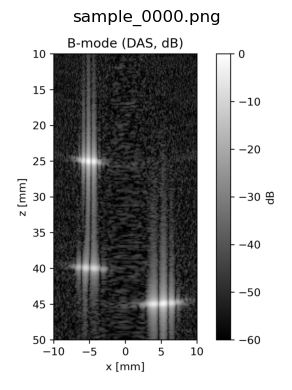

In [23]:
out_config_override = out_root / "config_override"
if out_config_override.exists():
    shutil.rmtree(out_config_override)

run_cli([
    "--config", "parameters/parameters1.json",
    "--scene", "scene/scene_simple.json",
    "--snr", "20",
    "--nelem", "64",
    "--out", str(out_config_override),
    "--num", "1",
    "--seed", "99"
])

manifest_config = read_run_json(out_config_override)
print("Nelem final:", manifest_config["parameters"]["Nelem"])
print("SNR final:", manifest_config["parameters"]["SNR_dB"])
display_generated_images(out_config_override, title="Images générées (config + overrides)")


## 9) Génération aléatoire (`--num`, `--max-point`)

Sans scène fournie, le simulateur génère des scènes aléatoires par image.

$ /usr/bin/python main.py --num 3 --max-point 5 --seed 2026 --out /home/tom/3A/PROCOM/code/demo/out/random_batch
Saved: /home/tom/3A/PROCOM/code/demo/out/random_batch/h5/sample_0000.h5
Saved: /home/tom/3A/PROCOM/code/demo/out/random_batch/h5/sample_0001.h5
Saved: /home/tom/3A/PROCOM/code/demo/out/random_batch/h5/sample_0002.h5

{
  "beamforming": "das",
  "cli": {
    "command": "simulate",
    "config": null,
    "dry_run": false,
    "max_point": 5,
    "mvdr": false,
    "nelem": null,
    "num": 3,
    "out": "/home/tom/3A/PROCOM/code/demo/out/random_batch",
    "preview_scene": false,
    "scene_path": null,
    "seed": 2026,
    "snr": null
  },
  "created_at": "2026-03-16T09:18:08.065746+00:00",
  "git_revision": null,
  "num_images": 3,
  "outputs": [
    {
      "h5": "/home/tom/3A/PROCOM/code/demo/out/random_batch/h5/sample_0000.h5",
      "index": 0,
      "png": "/home/tom/3A/PROCOM/code/demo/out/random_batch/images/sample_0000.png",
      "scene": {
        "layers": [],
 

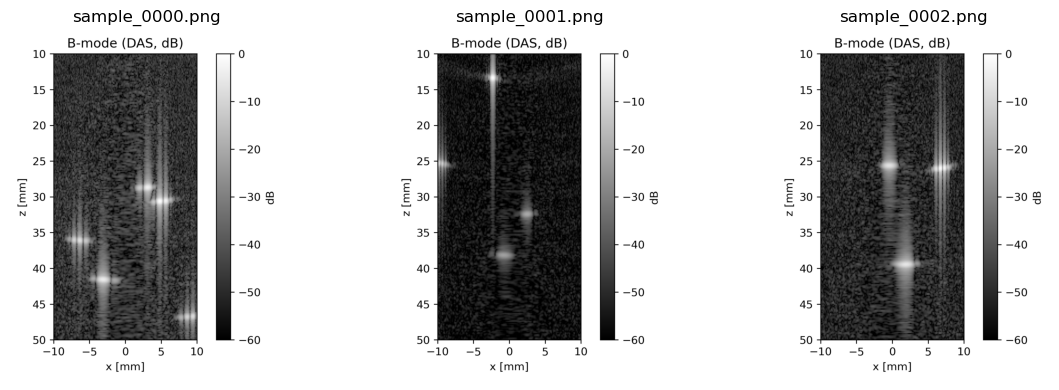

In [24]:
out_random = out_root / "random_batch"
if out_random.exists():
    shutil.rmtree(out_random)

run_cli([
    "--num", "3",
    "--max-point", "5",
    "--seed", "2026",
    "--out", str(out_random)
])

manifest_random = read_run_json(out_random)
print("Nb outputs:", len(manifest_random["outputs"]))
print("Seeds:", [o["seed"] for o in manifest_random["outputs"]])
print("Nb points/image:", [len(o["scene"]["points"]) for o in manifest_random["outputs"]])
display_generated_images(out_random, title="Images générées (batch aléatoire)")


## 10) Mode MVDR (`--mvdr`)

Exécution MVDR avec nommage de fichier spécifique (`*_mvdr.h5`).

$ /usr/bin/python main.py simulate --scene scene/scene_simple.json --mvdr --out /home/tom/3A/PROCOM/code/demo/out/mvdr_scene --num 1 --seed 42
MVDR Grid: 128x128 | Alignement des signaux...
Calcul des poids (Inv Covariance)...
Saved: /home/tom/3A/PROCOM/code/demo/out/mvdr_scene/h5/sample_0000_mvdr.h5

MVDR H5: [PosixPath('/home/tom/3A/PROCOM/code/demo/out/mvdr_scene/h5/sample_0000_mvdr.h5')]
{
  "beamforming": "mvdr",
  "cli": {
    "command": "simulate",
    "config": null,
    "dry_run": false,
    "max_point": 3,
    "mvdr": true,
    "nelem": null,
    "num": 1,
    "out": "/home/tom/3A/PROCOM/code/demo/out/mvdr_scene",
    "preview_scene": false,
    "scene_path": "scene/scene_simple.json",
    "seed": 42,
    "snr": null
  },
  "created_at": "2026-03-16T09:18:13.087811+00:00",
  "git_revision": null,
  "num_images": 1,
  "outputs": [
    {
      "h5": "/home/tom/3A/PROCOM/code/demo/out/mvdr_scene/h5/sample_0000_mvdr.h5",
      "index": 0,
      "png": "/home/tom/3A/PROCOM/code/de

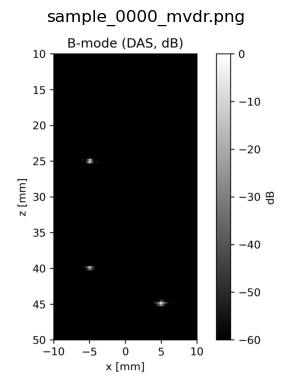

In [25]:
out_mvdr = out_root / "mvdr_scene"
if out_mvdr.exists():
    shutil.rmtree(out_mvdr)

run_cli([
    "simulate",
    "--scene", "scene/scene_simple.json",
    "--mvdr",
    "--out", str(out_mvdr),
    "--num", "1",
    "--seed", "42"
])

print("MVDR H5:", sorted((out_mvdr / "h5").glob("*.h5")))
manifest_mvdr = read_run_json(out_mvdr)
display_generated_images(out_mvdr, title="Images générées (MVDR)")


## 11) Vérification de reproductibilité (`--seed`)

Deux runs identiques (mêmes inputs + même seed) doivent produire des RF identiques.

In [26]:
out_rep_a = out_root / "repro_a"
out_rep_b = out_root / "repro_b"
for p in [out_rep_a, out_rep_b]:
    if p.exists():
        shutil.rmtree(p)

run_cli([
    "--scene", "scene/scene_simple.json",
    "--out", str(out_rep_a),
    "--num", "1",
    "--seed", "77"
])
run_cli([
    "--scene", "scene/scene_simple.json",
    "--out", str(out_rep_b),
    "--num", "1",
    "--seed", "77"
])

h5_a = sorted((out_rep_a / "h5").glob("*.h5"))[0]
h5_b = sorted((out_rep_b / "h5").glob("*.h5"))[0]
with h5py.File(h5_a, "r") as fa, h5py.File(h5_b, "r") as fb:
    rf_a = fa["rf"][:]
    rf_b = fb["rf"][:]

print("RF memes dimensions:", rf_a.shape, rf_b.shape)
print("RF strictement identiques:", np.array_equal(rf_a, rf_b))
print("Erreur max absolue:", np.max(np.abs(rf_a - rf_b)))


$ /usr/bin/python main.py --scene scene/scene_simple.json --out /home/tom/3A/PROCOM/code/demo/out/repro_a --num 1 --seed 77
Saved: /home/tom/3A/PROCOM/code/demo/out/repro_a/h5/sample_0000.h5

$ /usr/bin/python main.py --scene scene/scene_simple.json --out /home/tom/3A/PROCOM/code/demo/out/repro_b --num 1 --seed 77
Saved: /home/tom/3A/PROCOM/code/demo/out/repro_b/h5/sample_0000.h5

RF memes dimensions: (2679, 80) (2679, 80)
RF strictement identiques: True
Erreur max absolue: 0.0


## 12) Visualiser les images DAS et MVDR produites

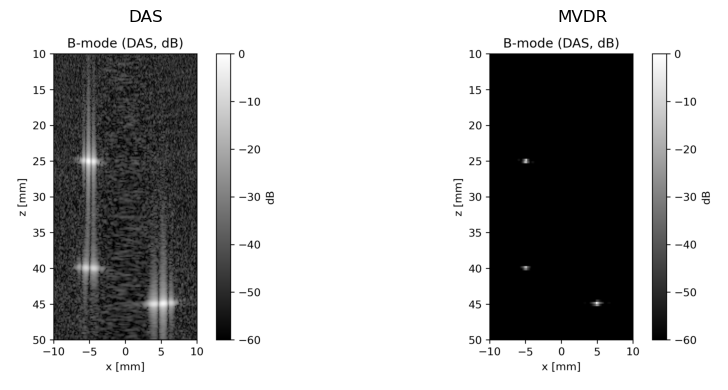

In [27]:
png_das = sorted((out_das_scene / "images").glob("*.png"))[0]
png_mvdr = sorted((out_mvdr / "images").glob("*.png"))[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, p, t in [(axes[0], png_das, "DAS"), (axes[1], png_mvdr, "MVDR")]:
    img = plt.imread(p)
    ax.imshow(img)
    ax.set_title(t)
    ax.axis("off")
plt.tight_layout()

## 13) Utilisation directe de l'API Python (`core`)

Exemple sans CLI: création paramètres + scène, simulation RF, beamforming DAS/MVDR.

In [28]:
from core import Parameters, Scene, ensure_seed, beamforming, mvdr_beamforming
from core.simulation import simulate_us_scene

params = Parameters(Nelem=48, Nx=128, Nz=128, SNR_dB=18.0)
params.validate()

scene_api = Scene(
    points=[
        [0.0e-3, 20.0e-3, 2.0],
        [2.0e-3, 30.0e-3, 1.5],
    ],
    layers=[]
)
scene_api.validate()

seed = ensure_seed(5)
rng = np.random.default_rng(seed)
rf = simulate_us_scene(params, scene_api, rng)
print("RF shape:", rf.shape)

das = beamforming(params, rf)
mvdr = mvdr_beamforming(params, rf)
print("DAS bmode:", das["bmode_dB"].shape)
print("MVDR bmode:", mvdr["bmode_dB"].shape)

RF shape: (2662, 48)
MVDR Grid: 128x128 | Alignement des signaux...
Calcul des poids (Inv Covariance)...
DAS bmode: (128, 128)
MVDR bmode: (128, 128)


## 14) Validation des erreurs (`ValidationError`)

Démonstration volontaire d'entrées invalides.

In [29]:
from core import ValidationError

# Paramètres invalides
try:
    bad = Parameters(Nelem=0)
    bad.validate()
except ValidationError as e:
    print("Paramètres invalides capturés:", e)

# Scène invalide (point mal formé)
try:
    Scene(points=[[0.0, 0.01]], layers=[]).validate()
except ValidationError as e:
    print("Scène invalide capturée:", e)

# CLI invalide: --preview-scene sans --scene
res = run_cli(["--preview-scene"], check=False)
print("Code retour attendu != 0:", res.returncode)

Paramètres invalides capturés: Invalid parameters: Nelem must be > 0
Scène invalide capturée: Point[0] must be a list of 3 values.
$ /usr/bin/python main.py --preview-scene
Error: --preview-scene requires --scene

Code retour attendu != 0: 2


## 15) Lecture HDF5: inspection de contenu

On inspecte quelques clés d'un fichier de sortie.

In [30]:
sample_h5 = sorted((out_das_scene / "h5").glob("*.h5"))[0]
with h5py.File(sample_h5, "r") as f:
    print("Top-level keys:", list(f.keys()))
    print("meta keys:", list(f["meta"].keys()))
    print("rf dtype / shape:", f["rf"].dtype, f["rf"].shape)
    print("bmode_dB min/max:", float(np.min(f["bmode_dB"][:])), float(np.max(f["bmode_dB"][:])))

Top-level keys: ['bmode_dB', 'env', 'meta', 'rf', 't', 'x_el', 'x_img', 'z_img']
meta keys: ['Nelem', 'SNR_dB', 'c', 'f0', 'fs', 'parameters', 'pitch', 'run_index', 'scene', 'seed', 'x_el', 'x_img', 'z_img']
rf dtype / shape: float32 (2679, 80)
bmode_dB min/max: -97.4330825805664 -9.318953743786551e-06


## 16) Résumé final

Ce notebook couvre l'ensemble des fonctionnalités exposées actuellement par le simulateur.
Vous pouvez réexécuter les cellules avec d'autres scènes (`scene/generated/*`) ou paramètres pour créer vos propres campagnes.

# II) Génération de Dataset

Dans cette section, nous allons définir plusieurs fonctions permettant d'exécuter le simulateur de manière répétitive et plus simple. Nous fournirons également un moyen de générer des configurations semi-aléatoires en JSON exécutables par la suite.

## 1) Fonction de simulation par batch

Cette fonction exécute le simulateur sur plusieurs scènes et collecte les résultats.

In [43]:
def run_batch_simulation(num_samples=None, max_points=5, seed=None, out_base=None, json_folder=None):
    """
    Exécute une batch de simulations avec des scènes aléatoires ou des fichiers JSON.
    
    Args:
        num_samples: Nombre d'images à générer (mode aléatoire, ignoré si json_folder est fourni)
        max_points: Nombre maximum de points brillants par scène (mode aléatoire)
        seed: Seed pour la reproductibilité (optionnel)
        out_base: Répertoire de sortie de base
        json_folder: Chemin vers un dossier contenant les fichiers JSON de scènes à simuler
                    Si fourni, exécute les simulations basées sur les JSON du dossier
        
    Returns:
        dict: Métadonnées de la simulation
    """
    if out_base is None:
        out_base = out_root / "batch_sim"
    
    out_dir = out_base
    if out_dir.exists():
        shutil.rmtree(out_dir)
    
    # Mode JSON: exécuter les scènes depuis le dossier
    if json_folder is not None:
        json_folder = Path(json_folder)
        if not json_folder.exists():
            raise ValueError(f"Le dossier JSON n'existe pas: {json_folder}")
        
        json_files = sorted(json_folder.glob("*.json"))
        if not json_files:
            raise ValueError(f"Aucun fichier JSON trouvé dans {json_folder}")
        
        print(f"Mode JSON: {len(json_files)} fichier(s) trouvé(s)")
        args = ["--out", str(out_dir)]
        
        # Exécuter pour chaque JSON
        for json_file in json_files:
            args_with_scene = ["--scene", str(json_file)] + args
            print(f"\nExécution pour scène: {json_file.name}")
            run_cli(args_with_scene)
        
        return read_run_json(out_dir)
    
    # Mode aléatoire (comportement par défaut)
    else:
        if num_samples is None:
            num_samples = 5
        
        args = ["--num", str(num_samples), "--max-point", str(max_points), "--out", str(out_dir)]
        if seed is not None:
            args.extend(["--seed", str(seed)])
        
        run_cli(args)
        return read_run_json(out_dir)

# Exemple 1: Mode aléatoire (comportement par défaut)
print("=== Exemple 1: Batch aléatoire ===")
manifest_random = run_batch_simulation(num_samples=5, max_points=3, seed=2026)
print(f"Total d'images générées: {len(manifest_random['outputs'])}")

# Exemple 2: Mode JSON (utilise les fichiers générés précédemment)
print("\n=== Exemple 2: Batch à partir de fichiers JSON ===")
manifest_json = run_batch_simulation(
    out_base=out_root / "batch_from_json",
    json_folder=out_root / "generated_scenes_points"
)
print(f"Total d'images générées: {len(manifest_json['outputs'])}")

=== Exemple 1: Batch aléatoire ===
$ /usr/bin/python main.py --num 5 --max-point 3 --out /home/tom/3A/PROCOM/code/demo/out/batch_sim --seed 2026
Saved: /home/tom/3A/PROCOM/code/demo/out/batch_sim/h5/sample_0000.h5
Saved: /home/tom/3A/PROCOM/code/demo/out/batch_sim/h5/sample_0001.h5
Saved: /home/tom/3A/PROCOM/code/demo/out/batch_sim/h5/sample_0002.h5
Saved: /home/tom/3A/PROCOM/code/demo/out/batch_sim/h5/sample_0003.h5
Saved: /home/tom/3A/PROCOM/code/demo/out/batch_sim/h5/sample_0004.h5

{
  "beamforming": "das",
  "cli": {
    "command": "simulate",
    "config": null,
    "dry_run": false,
    "max_point": 3,
    "mvdr": false,
    "nelem": null,
    "num": 5,
    "out": "/home/tom/3A/PROCOM/code/demo/out/batch_sim",
    "preview_scene": false,
    "scene_path": null,
    "seed": 2026,
    "snr": null
  },
  "created_at": "2026-03-16T09:27:01.760950+00:00",
  "git_revision": null,
  "num_images": 5,
  "outputs": [
    {
      "h5": "/home/tom/3A/PROCOM/code/demo/out/batch_sim/h5/sample

## 2) Générateur de configurations aléatoires

Cette fonction génère des fichiers JSON de configuration semi-aléatoires.

In [44]:
def generate_random_config_json(
    num_configs=3,
    out_dir=None,
    num_layers=None,
    num_points=None,
    layer_depth_min=0.005,
    layer_depth_max=0.040,
    points_count_min=None,
    points_count_max=None
):
    """
    Génère des fichiers JSON de scène semi-aléatoires avec couches et/ou points brillants.
    
    Args:
        num_configs: Nombre de configurations à générer
        out_dir: Répertoire de sortie
        num_layers: Nombre de couches (None = random entre 0 et 3)
        num_points: Nombre de points brillants (None = random entre 0 et 5)
        layer_depth_min: Profondeur minimale des couches en mètres
        layer_depth_max: Profondeur maximale des couches en mètres
        points_count_min: Nombre minimum de points brillants (overrides num_points si défini)
        points_count_max: Nombre maximum de points brillants (overrides num_points si défini)
    
    Returns:
        list: Liste des scènes générées
    """
    if out_dir is None:
        out_dir = out_root / "generated_configs"
    
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    
    scenes = []
    
    for i in range(num_configs):
        # Déterminer le nombre de couches
        if num_layers is None:
            n_layers = np.random.randint(0, 4)  # 0 à 3 couches
        else:
            n_layers = num_layers
        
        # Déterminer le nombre de points brillants
        if points_count_min is not None or points_count_max is not None:
            min_pts = points_count_min or 0
            max_pts = points_count_max or 8
            n_points = np.random.randint(min_pts, max_pts + 1)
        elif num_points is None:
            n_points = np.random.randint(0, 6)  # 0 à 5 points
        else:
            n_points = num_points
        
        # Générer les points brillants
        points = []
        if n_points > 0:
            for _ in range(n_points):
                x = float(np.random.uniform(-5e-3, 5e-3))
                z = float(np.random.uniform(10e-3, 40e-3))
                amplitude = float(np.random.uniform(0.5, 3.0))
                points.append([x, z, amplitude])
        
        # Générer les couches
        layers = []
        if n_layers > 0:
            layer_depth_step = (layer_depth_max - layer_depth_min) / n_layers
            z_current = layer_depth_min
            
            for j in range(n_layers):
                z_min = z_current
                z_max = z_current + layer_depth_step
                
                layer = {
                    "z_min": float(z_min),
                    "z_max": float(z_max),
                    "c": float(np.random.uniform(1450, 1600)),  # Vitesse acoustique en m/s
                    "rho": float(np.random.uniform(1000, 1100)),  # Densité en kg/m³
                    "name": f"Layer_{j+1}"
                }
                layers.append(layer)
                z_current = z_max
        
        # Créer la scène
        scene = {
            "points": points,
            "layers": layers
        }
        
        scene_path = out_dir / f"scene_{i:02d}.json"
        scene_path.write_text(json.dumps(scene, indent=2), encoding="utf-8")
        scenes.append(scene)
        
        print(f"Généré: {scene_path.name} ({n_points} point(s), {n_layers} couche(s))")
    
    return scenes

# Exemples d'utilisation
print("=== Exemple 1: Configuration aléatoire par défaut ===")
scenes_random = generate_random_config_json(num_configs=2)

print("\n=== Exemple 2: Seulement des couches (3 couches, 0 point) ===")
scenes_layers = generate_random_config_json(
    num_configs=2,
    out_dir=out_root / "generated_scenes_layers",
    num_layers=3,
    num_points=0
)

print("\n=== Exemple 3: Seulement des points (0 couche, 4-6 points) ===")
scenes_points = generate_random_config_json(
    num_configs=2,
    out_dir=out_root / "generated_scenes_points",
    num_layers=0,
    points_count_min=4,
    points_count_max=6
)

=== Exemple 1: Configuration aléatoire par défaut ===
Généré: scene_00.json (3 point(s), 3 couche(s))
Généré: scene_01.json (5 point(s), 1 couche(s))

=== Exemple 2: Seulement des couches (3 couches, 0 point) ===
Généré: scene_00.json (0 point(s), 3 couche(s))
Généré: scene_01.json (0 point(s), 3 couche(s))

=== Exemple 3: Seulement des points (0 couche, 4-6 points) ===
Généré: scene_00.json (6 point(s), 0 couche(s))
Généré: scene_01.json (6 point(s), 0 couche(s))


## 3) On lance les exemples


DÉMONSTRATION: Génération + Simulation en batch

📋 Étape 1: Génération de 5 scènes semi-aléatoires...
Généré: scene_00.json (1 point(s), 3 couche(s))
Généré: scene_01.json (5 point(s), 1 couche(s))
Généré: scene_02.json (3 point(s), 3 couche(s))
Généré: scene_03.json (0 point(s), 0 couche(s))
Généré: scene_04.json (0 point(s), 1 couche(s))

📊 Détail des scènes générées:
  Scene 0: 1 point(s) brillant(s), 3 couche(s)
  Scene 1: 5 point(s) brillant(s), 1 couche(s)
  Scene 2: 3 point(s) brillant(s), 3 couche(s)
  Scene 3: 0 point(s) brillant(s), 0 couche(s)
  Scene 4: 0 point(s) brillant(s), 1 couche(s)

🚀 Étape 2: Simulation en batch de toutes les scènes...
   Dossier source: /home/tom/3A/PROCOM/code/demo/out/demo_batch_scenes
Mode JSON: 5 fichier(s) trouvé(s)

Exécution pour scène: scene_00.json
$ /usr/bin/python main.py --scene /home/tom/3A/PROCOM/code/demo/out/demo_batch_scenes/scene_00.json --out /home/tom/3A/PROCOM/code/demo/out/demo_batch_results
Saved: /home/tom/3A/PROCOM/code/dem

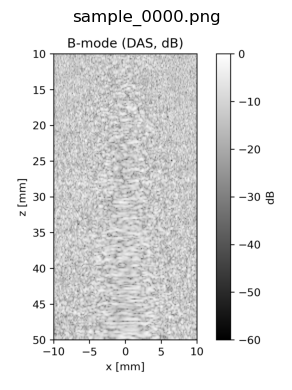


✅ Démonstration terminée!

💡 Points clés:
   - Génération programmatique de scènes JSON
   - Simulation en batch avec un seul appel de fonction
   - Résultats organisés (HDF5 + images)
   - Facilement extensible pour créer des datasets larges


In [45]:
# Exemple complet: Générer des scènes JSON puis les simuler en batch
print("=" * 60)
print("DÉMONSTRATION: Génération + Simulation en batch")
print("=" * 60)

# Étape 1: Générer 5 scènes mixtes (points + couches)
print("\n📋 Étape 1: Génération de 5 scènes semi-aléatoires...")
demo_scenes_dir = out_root / "demo_batch_scenes"
scenes = generate_random_config_json(
    num_configs=5,
    out_dir=demo_scenes_dir,
    layer_depth_min=0.005,
    layer_depth_max=0.030
)

# Afficher les détails des scènes générées
print("\n📊 Détail des scènes générées:")
for i, scene in enumerate(scenes):
    n_pts = len(scene["points"])
    n_layers = len(scene["layers"])
    print(f"  Scene {i}: {n_pts} point(s) brillant(s), {n_layers} couche(s)")

# Étape 2: Simuler toutes les scènes en batch
print("\n🚀 Étape 2: Simulation en batch de toutes les scènes...")
print(f"   Dossier source: {demo_scenes_dir}")

manifest_batch = run_batch_simulation(
    out_base=out_root / "demo_batch_results",
    json_folder=demo_scenes_dir
)

# Étape 3: Analyser les résultats
print("\n📈 Étape 3: Analyse des résultats")
print(f"   Nombre total d'images générées: {len(manifest_batch['outputs'])}")
print(f"   Dossier de sortie: {out_root / 'demo_batch_results'}")

# Afficher les fichiers générés
h5_files = sorted((out_root / "demo_batch_results" / "h5").glob("*.h5"))
img_files = sorted((out_root / "demo_batch_results" / "images").glob("*.png"))

print(f"\n   Fichiers HDF5: {len(h5_files)} fichier(s)")
for h5 in h5_files[:3]:
    print(f"     - {h5.name}")
if len(h5_files) > 3:
    print(f"     ... et {len(h5_files) - 3} autre(s)")

print(f"\n   Images PNG: {len(img_files)} image(s)")
for img in img_files[:3]:
    print(f"     - {img.name}")
if len(img_files) > 3:
    print(f"     ... et {len(img_files) - 3} autre(s)")

# Étape 4: Afficher un aperçu des images
print("\n🎨 Étape 4: Aperçu des images générées")
display_generated_images(
    out_root / "demo_batch_results",
    title="Résultats du batch: Mix de points brillants et couches",
    max_images=9
)

print("\n✅ Démonstration terminée!")
print("\n💡 Points clés:")
print("   - Génération programmatique de scènes JSON")
print("   - Simulation en batch avec un seul appel de fonction")
print("   - Résultats organisés (HDF5 + images)")
print("   - Facilement extensible pour créer des datasets larges")

# III) Cas générables avec le simulateur

Dans cette section finale, nous simulerons les deux cas principaux du simulateur : d'abord des points brillants, puis des couches.

## 1) Simulation de points brillants

Les points brillants (scatterers) sont les cibles ponctuelles classiques en imagerie échographique.

$ /usr/bin/python main.py --num 3 --max-point 8 --out /home/tom/3A/PROCOM/code/demo/out/case_points --seed 1001
Saved: /home/tom/3A/PROCOM/code/demo/out/case_points/h5/sample_0000.h5
Saved: /home/tom/3A/PROCOM/code/demo/out/case_points/h5/sample_0001.h5
Saved: /home/tom/3A/PROCOM/code/demo/out/case_points/h5/sample_0002.h5

{
  "beamforming": "das",
  "cli": {
    "command": "simulate",
    "config": null,
    "dry_run": false,
    "max_point": 8,
    "mvdr": false,
    "nelem": null,
    "num": 3,
    "out": "/home/tom/3A/PROCOM/code/demo/out/case_points",
    "preview_scene": false,
    "scene_path": null,
    "seed": 1001,
    "snr": null
  },
  "created_at": "2026-03-16T09:18:26.199541+00:00",
  "git_revision": null,
  "num_images": 3,
  "outputs": [
    {
      "h5": "/home/tom/3A/PROCOM/code/demo/out/case_points/h5/sample_0000.h5",
      "index": 0,
      "png": "/home/tom/3A/PROCOM/code/demo/out/case_points/images/sample_0000.png",
      "scene": {
        "layers": [],
        

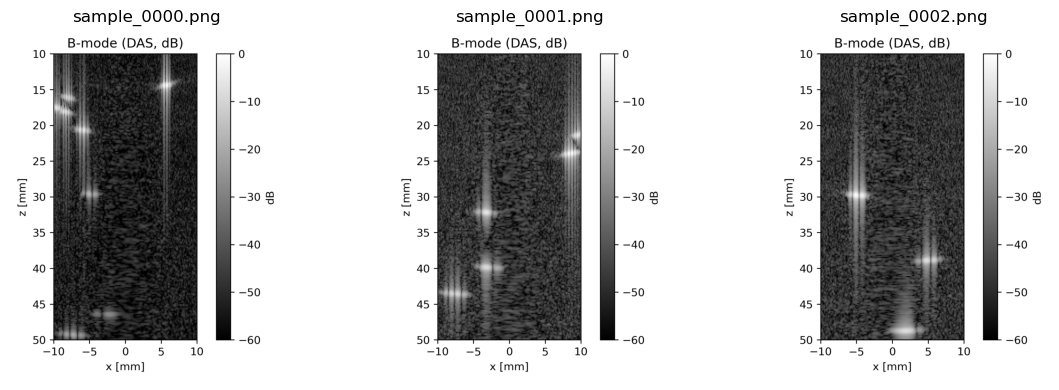

In [33]:
out_points = out_root / "case_points"
if out_points.exists():
    shutil.rmtree(out_points)

run_cli([
    "--num", "3",
    "--max-point", "8",
    "--out", str(out_points),
    "--seed", "1001"
])

manifest_points = read_run_json(out_points)
print("Cas points brillants:")
for i, output in enumerate(manifest_points["outputs"]):
    print(f"  Image {i}: {len(output['scene']['points'])} point(s)")

display_generated_images(out_points, title="Cas points brillants", max_images=6)

## 2) Simulation de couches

Les couches (layers) représentent des interfaces acoustiques parallèles, typiques des structures biologiques.

$ /usr/bin/python main.py --scene /home/tom/3A/PROCOM/code/demo/out/scene_layers.json --out /home/tom/3A/PROCOM/code/demo/out/case_layers --num 2 --seed 2001 --mvdr
MVDR Grid: 128x128 | Alignement des signaux...
Calcul des poids (Inv Covariance)...
Saved: /home/tom/3A/PROCOM/code/demo/out/case_layers/h5/sample_0000_mvdr.h5
MVDR Grid: 128x128 | Alignement des signaux...
Calcul des poids (Inv Covariance)...
Saved: /home/tom/3A/PROCOM/code/demo/out/case_layers/h5/sample_0001_mvdr.h5

{
  "beamforming": "mvdr",
  "cli": {
    "command": "simulate",
    "config": null,
    "dry_run": false,
    "max_point": 3,
    "mvdr": true,
    "nelem": null,
    "num": 2,
    "out": "/home/tom/3A/PROCOM/code/demo/out/case_layers",
    "preview_scene": false,
    "scene_path": "/home/tom/3A/PROCOM/code/demo/out/scene_layers.json",
    "seed": 2001,
    "snr": null
  },
  "created_at": "2026-03-16T09:28:19.559463+00:00",
  "git_revision": null,
  "num_images": 2,
  "outputs": [
    {
      "h5": "/home/t

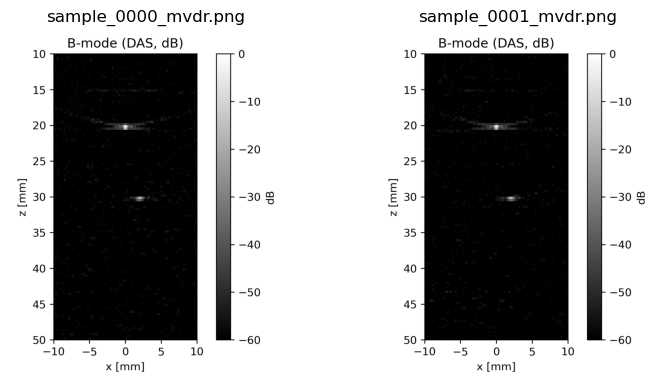

In [47]:
scene_with_layers = {
    "points": [
        [0.0e-3, 20.0e-3, 22.0],
        [2.0e-3, 30.0e-3, 12.5],
    ],
    "layers": [
        {
            "z_min": 0.015,
            "z_max": 0.025,
            "c": 1500.0,
            "rho": 1050.0,
            "name": "Couche 2"
        },
        {
            "z_min": 0.025,
            "z_max": 0.035,
            "c": 1550.0,
            "rho": 1020.0,
            "name": "Couche 3"
        }
    ]
}

layers_scene_path = out_root / "scene_layers.json"
layers_scene_path.write_text(json.dumps(scene_with_layers, indent=2), encoding="utf-8")

out_layers = out_root / "case_layers"
if out_layers.exists():
    shutil.rmtree(out_layers)

run_cli([
    "--scene", str(layers_scene_path),
    "--out", str(out_layers),
    "--num", "2",
    "--seed", "2001",
    "--mvdr"
])

manifest_layers = read_run_json(out_layers)
print("Cas couches:")
for i, output in enumerate(manifest_layers["outputs"]):
    print(f"  Image {i}: {len(output['scene']['layers'])} couche(s)")

display_generated_images(out_layers, title="Cas couches", max_images=6)

## 3) Comparaison: points vs couches

Comparaison visuelle des deux modes de simulation.

In [35]:
png_points = sorted((out_points / "images").glob("*.png"))
png_layers = sorted((out_layers / "images").glob("*.png"))

if png_points and png_layers:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes[0, 0].imshow(plt.imread(png_points[0]))
    axes[0, 0].set_title("Points brillants (1)")
    axes[0, 0].axis("off")
    
    if len(png_points) > 1:
        axes[0, 1].imshow(plt.imread(png_points[1]))
        axes[0, 1].set_title("Points brillants (2)")
        axes[0, 1].axis("off")
    else:
        axes[0, 1].axis("off")
    
    axes[1, 0].imshow(plt.imread(png_layers[0]))
    axes[1, 0].set_title("Couches (1)")
    axes[1, 0].axis("off")
    
    if len(png_layers) > 1:
        axes[1, 1].imshow(plt.imread(png_layers[1]))
        axes[1, 1].set_title("Couches (2)")
        axes[1, 1].axis("off")
    else:
        axes[1, 1].axis("off")
    
    plt.tight_layout()
    plt.show()